# PerfX SDK Overhead Analysis
Compares CPU usage, memory, and startup time between **withSdk** and **noSdk** Cheddar builds.

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

RESULTS = os.path.join(os.path.dirname(os.path.abspath('.')), 'Android', 'results')
# If running from the Android/ folde
# r directly:
RESULTS = '../results/Redmi_Note_9_Pro'

## 1. Load data

In [58]:
with_sdk = pd.read_csv(f'{RESULTS}/withSdk.csv')
no_sdk   = pd.read_csv(f'{RESULTS}/noSdk.csv')

startup_with = pd.read_csv(f'{RESULTS}/withSdk_startup.txt').squeeze()
startup_no   = pd.read_csv(f'{RESULTS}/noSdk_startup.txt').squeeze()

# Convert PSS and Java heap from KB to MB
for df in [with_sdk, no_sdk]:
    df['pss_mb']       = df['pss_kb'] / 1024
    df['java_heap_mb'] = df['java_heap_kb'] / 1024

print('withSdk samples:', len(with_sdk))
print('noSdk   samples:', len(no_sdk))
with_sdk.head()

withSdk samples: 90
noSdk   samples: 90


,timestamp_s,cpu_pct,pss_kb,java_heap_kb,pss_mb,java_heap_mb
0,1,347.41,207417,266620,202.555664,260.371094
1,2,99.17,178597,268528,174.411133,262.234375
2,3,132.17,181841,271844,177.579102,265.472656
3,4,79.13,181663,271760,177.405273,265.390625
4,5,91.53,181230,271892,176.982422,265.519531


## 2. Summary table

In [59]:
def overhead(with_val, no_val, unit=''):
    delta = with_val - no_val
    pct   = delta / no_val * 100 if no_val != 0 else float('nan')
    return f'+{delta:.2f}{unit} (+{pct:.1f}%)' if delta >= 0 else f'{delta:.2f}{unit} ({pct:.1f}%)'

rows = [
    ('Cold startup time (ms)',
     f'{startup_no.mean():.1f}',
     f'{startup_with.mean():.1f}',
     overhead(startup_with.mean(), startup_no.mean(), ' ms')),

    ('Avg CPU usage (%)',
     f'{no_sdk.cpu_pct.mean():.2f}',
     f'{with_sdk.cpu_pct.mean():.2f}',
     overhead(with_sdk.cpu_pct.mean(), no_sdk.cpu_pct.mean(), '%')),

    ('Avg PSS memory (MB)',
     f'{no_sdk.pss_mb.mean():.1f}',
     f'{with_sdk.pss_mb.mean():.1f}',
     overhead(with_sdk.pss_mb.mean(), no_sdk.pss_mb.mean(), ' MB')),

    ('Avg Java heap (MB)',
     f'{no_sdk.java_heap_mb.mean():.1f}',
     f'{with_sdk.java_heap_mb.mean():.1f}',
     overhead(with_sdk.java_heap_mb.mean(), no_sdk.java_heap_mb.mean(), ' MB')),
]

summary = pd.DataFrame(rows, columns=['Metric', 'Without SDK', 'With SDK', 'Overhead'])
summary

,Metric,Without SDK,With SDK,Overhead
0,Cold startup time (ms),1483.7,1559.4,+75.70 ms (+5.1%)
1,Avg CPU usage (%),94.61,95.41,+0.80% (+0.8%)
2,Avg PSS memory (MB),220.1,222.0,+1.91 MB (+0.9%)
3,Avg Java heap (MB),304.2,308.3,+4.05 MB (+1.3%)


## 3. CPU usage over time

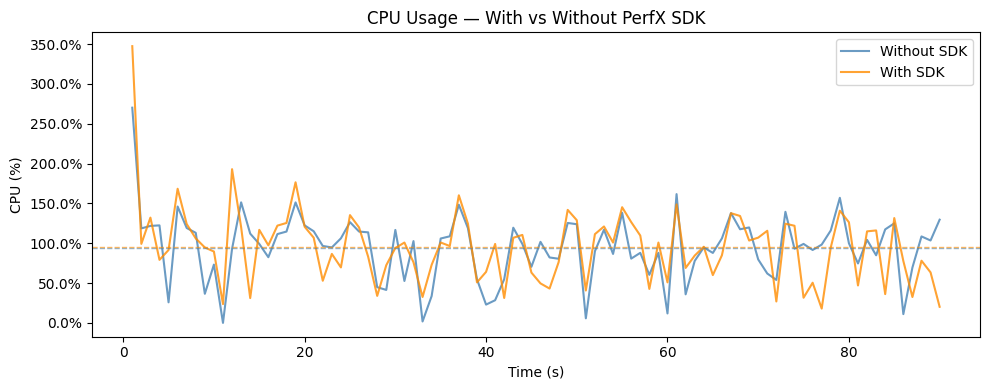

In [60]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(no_sdk.timestamp_s,   no_sdk.cpu_pct,   label='Without SDK', color='steelblue',  alpha=0.8)
ax.plot(with_sdk.timestamp_s, with_sdk.cpu_pct, label='With SDK',    color='darkorange', alpha=0.8)

ax.axhline(no_sdk.cpu_pct.mean(),   color='steelblue',  linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(with_sdk.cpu_pct.mean(), color='darkorange', linestyle='--', linewidth=1, alpha=0.6)

ax.set_xlabel('Time (s)')
ax.set_ylabel('CPU (%)')
ax.set_title('CPU Usage — With vs Without PerfX SDK')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.savefig(f'{RESULTS}/cpu_overhead.png', dpi=150)
plt.show()

## 4. Memory (PSS) over time

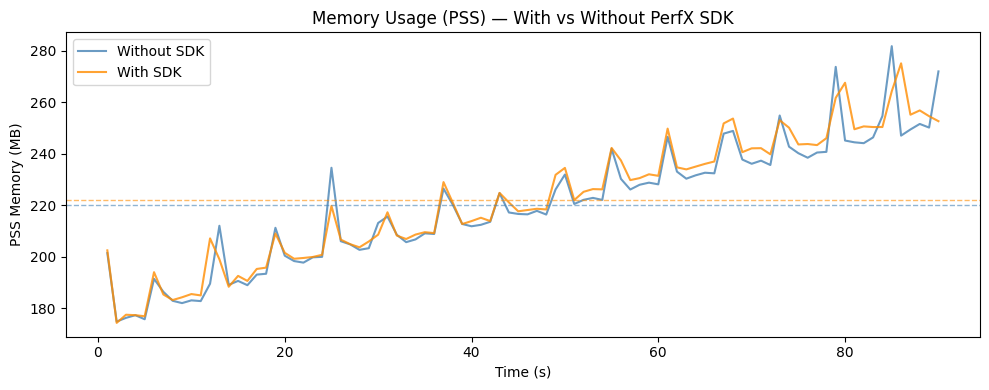

In [61]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(no_sdk.timestamp_s,   no_sdk.pss_mb,   label='Without SDK', color='steelblue',  alpha=0.8)
ax.plot(with_sdk.timestamp_s, with_sdk.pss_mb, label='With SDK',    color='darkorange', alpha=0.8)

ax.axhline(no_sdk.pss_mb.mean(),   color='steelblue',  linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(with_sdk.pss_mb.mean(), color='darkorange', linestyle='--', linewidth=1, alpha=0.6)

ax.set_xlabel('Time (s)')
ax.set_ylabel('PSS Memory (MB)')
ax.set_title('Memory Usage (PSS) — With vs Without PerfX SDK')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS}/memory_overhead.png', dpi=150)
plt.show()

## 5. Startup time distribution

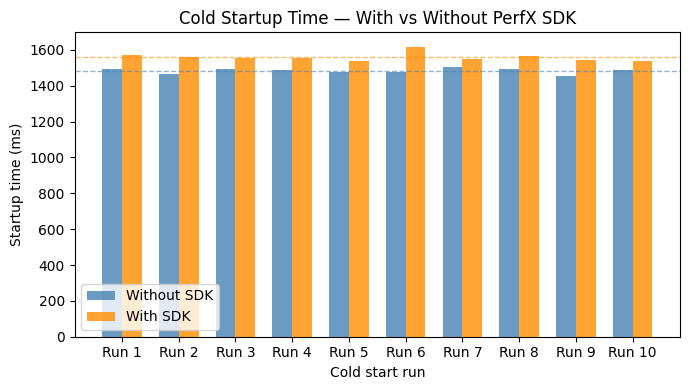

In [62]:
fig, ax = plt.subplots(figsize=(7, 4))

x     = np.arange(len(startup_no))
width = 0.35

ax.bar(x - width/2, startup_no.values,   width, label='Without SDK', color='steelblue',  alpha=0.8)
ax.bar(x + width/2, startup_with.values, width, label='With SDK',    color='darkorange', alpha=0.8)

ax.axhline(startup_no.mean(),   color='steelblue',  linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(startup_with.mean(), color='darkorange', linestyle='--', linewidth=1, alpha=0.6)

ax.set_xlabel('Cold start run')
ax.set_ylabel('Startup time (ms)')
ax.set_title('Cold Startup Time — With vs Without PerfX SDK')
ax.set_xticks(x)
ax.set_xticklabels([f'Run {i+1}' for i in x])
ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS}/startup_overhead.png', dpi=150)
plt.show()

## 6. Combined bar chart (for thesis)

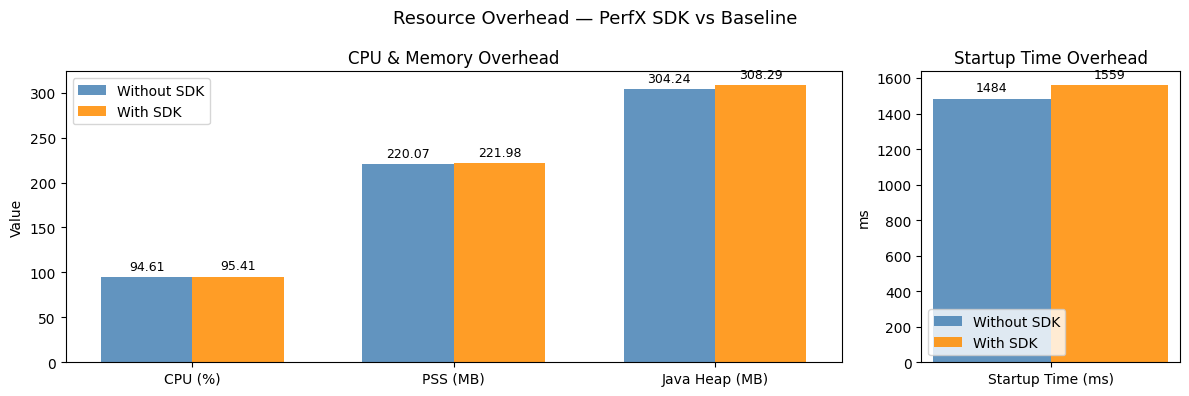

In [63]:
metrics = ['CPU (%)', 'PSS (MB)', 'Java Heap (MB)', 'Startup Time (ms)']
no_vals   = [no_sdk.cpu_pct.mean(),   no_sdk.pss_mb.mean(),   no_sdk.java_heap_mb.mean(),   startup_no.mean()]
with_vals = [with_sdk.cpu_pct.mean(), with_sdk.pss_mb.mean(), with_sdk.java_heap_mb.mean(), startup_with.mean()]

x = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [3, 1]})

# Left: CPU, PSS, Java Heap (similar scale)
ax1 = axes[0]
b1 = ax1.bar(x[:3] - width/2, no_vals[:3],   width, label='Without SDK', color='steelblue',  alpha=0.85)
b2 = ax1.bar(x[:3] + width/2, with_vals[:3],  width, label='With SDK',    color='darkorange', alpha=0.85)
ax1.bar_label(b1, fmt='%.2f', padding=3, fontsize=9)
ax1.bar_label(b2, fmt='%.2f', padding=3, fontsize=9)
ax1.set_xticks(x[:3])
ax1.set_xticklabels(metrics[:3])
ax1.set_ylabel('Value')
ax1.set_title('CPU & Memory Overhead')
ax1.legend()

# Right: Startup time (different scale)
ax2 = axes[1]
b3 = ax2.bar([-width/2], [no_vals[3]],   width, label='Without SDK', color='steelblue',  alpha=0.85)
b4 = ax2.bar([+width/2], [with_vals[3]], width, label='With SDK',    color='darkorange', alpha=0.85)
ax2.bar_label(b3, fmt='%.0f', padding=3, fontsize=9)
ax2.bar_label(b4, fmt='%.0f', padding=3, fontsize=9)
ax2.set_xticks([0])
ax2.set_xticklabels(['Startup Time (ms)'])
ax2.set_ylabel('ms')
ax2.set_title('Startup Time Overhead')
ax2.legend()

plt.suptitle('Resource Overhead — PerfX SDK vs Baseline', fontsize=13)
plt.tight_layout()
plt.savefig(f'{RESULTS}/overhead_summary.png', dpi=150)
plt.show()

---
## SDK Accuracy Analysis
Compares SDK-reported values against adb ground truth collected in the same time window.
Run `./measure_accuracy.sh <project_id>` first to generate the data.

In [64]:
from scipy import stats

ACC = os.path.join(RESULTS, 'accuracy')

def load_csv_or_empty(path, names):
    try:
        df = pd.read_csv(path, names=names, header=0)
        return df if not df.empty else pd.DataFrame(columns=names)
    except FileNotFoundError:
        print(f"  [missing] {path}")
        return pd.DataFrame(columns=names)

# ── load ──────────────────────────────────────────────────────────────────────
startup_gt  = pd.read_csv(f'{ACC}/startup_groundtruth.txt').squeeze()
startup_sdk = load_csv_or_empty(f'{ACC}/startup_sdk.csv',
                                ['timestamp_s', 'startup_ms'])['startup_ms']

sys_gt  = pd.read_csv(f'{ACC}/system_groundtruth.csv')
cpu_sdk = load_csv_or_empty(f'{ACC}/cpu_sdk.csv', ['timestamp_s', 'cpu_pct'])
ram_sdk = load_csv_or_empty(f'{ACC}/ram_sdk.csv', ['timestamp_s', 'ram_mb'])

frames_gt  = pd.read_csv(f'{ACC}/frames_groundtruth.csv').squeeze()
frames_sdk = load_csv_or_empty(f'{ACC}/frames_sdk.csv',
                               ['timestamp_s', 'frame_ms'])['frame_ms']

# normalise timestamps to seconds-from-start
sys_gt['t'] = sys_gt['timestamp_s'] - sys_gt['timestamp_s'].min()
for df in [cpu_sdk, ram_sdk]:
    if not df.empty:
        df['t'] = df['timestamp_s'] - df['timestamp_s'].min()
    else:
        df['t'] = pd.Series(dtype=float)

sdk_startup_ok = len(startup_sdk) > 0
sdk_cpu_ok     = not cpu_sdk.empty
sdk_ram_ok     = not ram_sdk.empty
sdk_frames_ok  = len(frames_sdk) > 0

print(f"Startup  — GT: {len(startup_gt)} runs  | SDK: {len(startup_sdk)} samples {'✓' if sdk_startup_ok else '✗ (no SDK data)'}")
print(f"CPU      — GT: {len(sys_gt)} s     | SDK: {len(cpu_sdk)} samples {'✓' if sdk_cpu_ok else '✗ (no SDK data)'}")
print(f"RAM      — GT: {len(sys_gt)} s     | SDK: {len(ram_sdk)} samples {'✓' if sdk_ram_ok else '✗ (no SDK data)'}")
print(f"Frames   — GT: {len(frames_gt)} frames | SDK: {len(frames_sdk)} samples {'✓' if sdk_frames_ok else '✗ (no SDK data)'}")

FileNotFoundError: [Errno 2] No such file or directory: '../results/Redmi_Note_9_Pro/accuracy/startup_groundtruth.txt'

### Accuracy summary table

In [ ]:
def accuracy_row(label, gt_series, sdk_series, unit):
    gt = gt_series.dropna()
    sdk = sdk_series.dropna()
    if len(sdk) == 0:
        return {'Metric': label, f'GT mean ({unit})': f'{gt.mean():.2f}',
                f'SDK mean ({unit})': 'N/A', 'MAE': 'N/A', 'Relative error': 'N/A'}
    mae = abs(gt.mean() - sdk.mean())
    mre = mae / gt.mean() * 100 if gt.mean() != 0 else float('nan')
    return {'Metric': label, f'GT mean ({unit})': f'{gt.mean():.2f}',
            f'SDK mean ({unit})': f'{sdk.mean():.2f}',
            'MAE': f'{mae:.2f} {unit}', 'Relative error': f'{mre:.1f}%'}

def align(gt_1s, sdk_df, col):
    """Align SDK samples onto the ground-truth 1-s index by nearest neighbour."""
    if sdk_df.empty:
        return gt_1s, pd.Series(np.nan, index=gt_1s.index)
    sdk_indexed = (sdk_df.set_index('t')[col]
                   .groupby(level=0).mean()
                   .sort_index())
    gt_deduped  = gt_1s.groupby(level=0).mean().sort_index()
    sdk_aligned = sdk_indexed.reindex(gt_deduped.index, method='nearest')
    return gt_deduped, sdk_aligned

cpu_gt_1s, cpu_sdk_1s = align(sys_gt.set_index('t')['cpu_pct'], cpu_sdk, 'cpu_pct')

# GT pss_kb is in KB → convert to MB; SDK value is already in MB (javaHeapUsedMb)
ram_gt_mb,  ram_sdk_mb  = align(sys_gt.set_index('t')['pss_kb'] / 1024, ram_sdk, 'ram_mb')

rows = [
    accuracy_row('Startup time', startup_gt, startup_sdk, 'ms'),
    accuracy_row('CPU usage',    cpu_gt_1s,  cpu_sdk_1s,  '%'),
    accuracy_row('RAM (PSS)',    ram_gt_mb,  ram_sdk_mb,  'MB'),
    accuracy_row('Frame time',  frames_gt,  frames_sdk,  'ms'),
]
pd.DataFrame(rows)

,Metric,GT mean (ms),SDK mean (ms),MAE,Relative error,GT mean (%),SDK mean (%),GT mean (MB),SDK mean (MB)
0,Startup time,1574.00,1410.75,163.25 ms,10.4%,NaN,NaN,NaN,NaN
1,CPU usage,NaN,NaN,17.91 %,16.6%,107.97,125.88,NaN,NaN
2,RAM (PSS),NaN,NaN,16.78 MB,7.7%,NaN,NaN,217.71,200.93
3,Frame time,18.82,21.16,2.34 ms,12.5%,NaN,NaN,NaN,NaN


### Startup time — distribution comparison

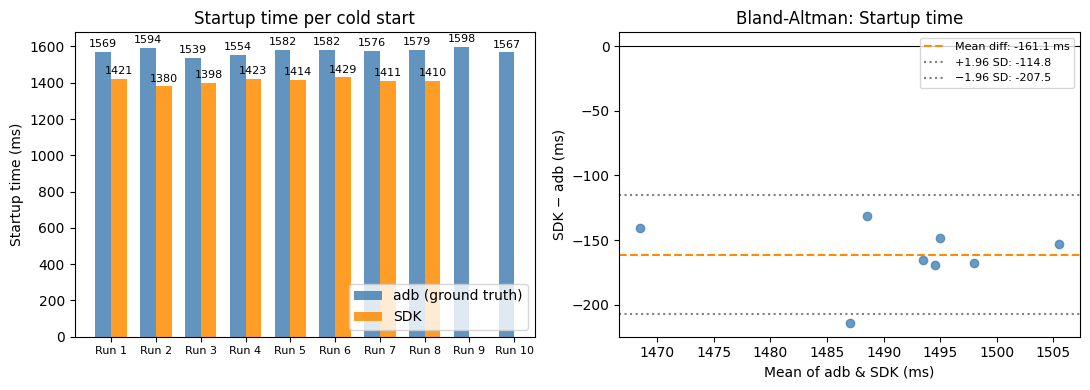

In [ ]:
fig, axes = plt.subplots(1, 2 if sdk_startup_ok else 1, figsize=(11 if sdk_startup_ok else 6, 4))
axes = np.atleast_1d(axes)

ax = axes[0]
x = np.arange(len(startup_gt))
w = 0.35 if sdk_startup_ok else 0.6
b1 = ax.bar(x - w/2 if sdk_startup_ok else x, startup_gt.values, w,
            label='adb (ground truth)', color='steelblue', alpha=0.85)
ax.bar_label(b1, fmt='%.0f', padding=2, fontsize=8)
if sdk_startup_ok:
    n = min(len(startup_gt), len(startup_sdk))
    b2 = ax.bar(x[:n] + w/2, startup_sdk.values[:n], w,
                label='SDK', color='darkorange', alpha=0.85)
    ax.bar_label(b2, fmt='%.0f', padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f'Run {i+1}' for i in x], fontsize=8)
ax.set_ylabel('Startup time (ms)')
ax.set_title('Startup time per cold start')
ax.legend()

if sdk_startup_ok:
    ax2 = axes[1]
    n = min(len(startup_gt), len(startup_sdk))
    means = (startup_gt.values[:n] + startup_sdk.values[:n]) / 2
    diffs = startup_sdk.values[:n] - startup_gt.values[:n]
    md, sd = diffs.mean(), diffs.std()
    ax2.scatter(means, diffs, color='steelblue', alpha=0.8)
    ax2.axhline(md,           color='darkorange', linestyle='--', label=f'Mean diff: {md:.1f} ms')
    ax2.axhline(md + 1.96*sd, color='gray', linestyle=':', label=f'+1.96 SD: {md+1.96*sd:.1f}')
    ax2.axhline(md - 1.96*sd, color='gray', linestyle=':', label=f'−1.96 SD: {md-1.96*sd:.1f}')
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_xlabel('Mean of adb & SDK (ms)')
    ax2.set_ylabel('SDK − adb (ms)')
    ax2.set_title('Bland-Altman: Startup time')
    ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{ACC}/accuracy_startup.png', dpi=150)
plt.show()

### CPU usage — time series comparison

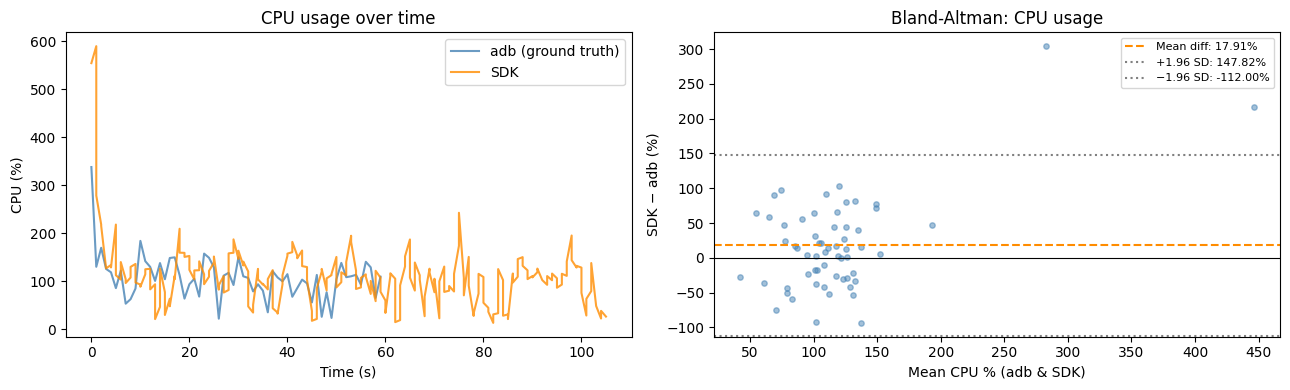

In [ ]:
fig, axes = plt.subplots(1, 2 if sdk_cpu_ok else 1, figsize=(13 if sdk_cpu_ok else 7, 4))
axes = np.atleast_1d(axes)

ax = axes[0]
ax.plot(sys_gt['t'], sys_gt['cpu_pct'], label='adb (ground truth)', color='steelblue', alpha=0.8)
if sdk_cpu_ok:
    ax.plot(cpu_sdk['t'], cpu_sdk['cpu_pct'], label='SDK', color='darkorange', alpha=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('CPU (%)')
ax.set_title('CPU usage over time')
ax.legend()

if sdk_cpu_ok:
    ax2 = axes[1]
    diffs = cpu_sdk_1s.values - cpu_gt_1s.values
    md, sd = np.nanmean(diffs), np.nanstd(diffs)
    means = (cpu_sdk_1s.values + cpu_gt_1s.values) / 2
    ax2.scatter(means, diffs, alpha=0.5, s=15, color='steelblue')
    ax2.axhline(md,           color='darkorange', linestyle='--', label=f'Mean diff: {md:.2f}%')
    ax2.axhline(md + 1.96*sd, color='gray', linestyle=':', label=f'+1.96 SD: {md+1.96*sd:.2f}%')
    ax2.axhline(md - 1.96*sd, color='gray', linestyle=':', label=f'−1.96 SD: {md-1.96*sd:.2f}%')
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_xlabel('Mean CPU % (adb & SDK)')
    ax2.set_ylabel('SDK − adb (%)')
    ax2.set_title('Bland-Altman: CPU usage')
    ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{ACC}/accuracy_cpu.png', dpi=150)
plt.show()

### RAM (PSS) — time series comparison

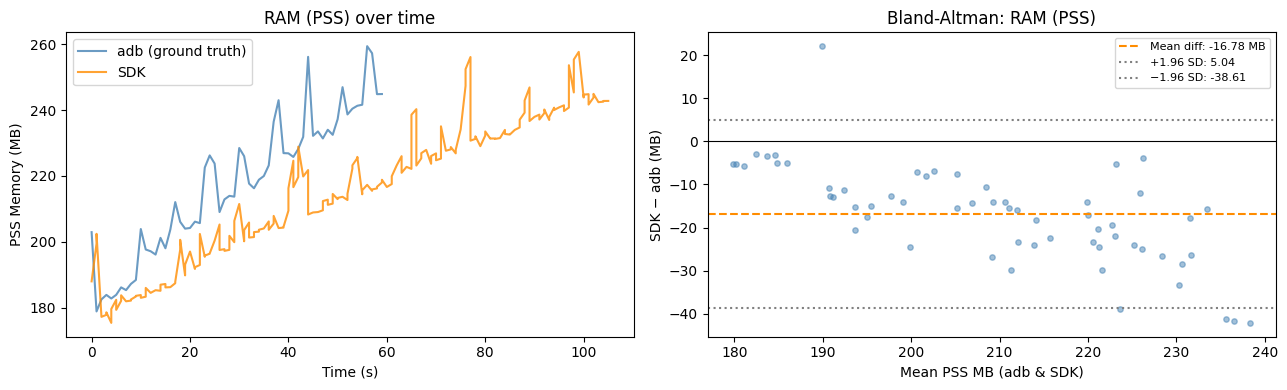

In [ ]:
fig, axes = plt.subplots(1, 2 if sdk_ram_ok else 1, figsize=(13 if sdk_ram_ok else 7, 4))
axes = np.atleast_1d(axes)

ax = axes[0]
ax.plot(sys_gt['t'], sys_gt['pss_kb'] / 1024, label='adb (ground truth)', color='steelblue', alpha=0.8)
if sdk_ram_ok:
    ax.plot(ram_sdk['t'], ram_sdk['ram_mb'], label='SDK', color='darkorange', alpha=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('PSS Memory (MB)')
ax.set_title('RAM (PSS) over time')
ax.legend()

if sdk_ram_ok:
    ax2 = axes[1]
    diffs = ram_sdk_mb.values - ram_gt_mb.values
    md, sd = np.nanmean(diffs), np.nanstd(diffs)
    means = (ram_sdk_mb.values + ram_gt_mb.values) / 2
    ax2.scatter(means, diffs, alpha=0.5, s=15, color='steelblue')
    ax2.axhline(md,           color='darkorange', linestyle='--', label=f'Mean diff: {md:.2f} MB')
    ax2.axhline(md + 1.96*sd, color='gray', linestyle=':', label=f'+1.96 SD: {md+1.96*sd:.2f}')
    ax2.axhline(md - 1.96*sd, color='gray', linestyle=':', label=f'−1.96 SD: {md-1.96*sd:.2f}')
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_xlabel('Mean PSS MB (adb & SDK)')
    ax2.set_ylabel('SDK − adb (MB)')
    ax2.set_title('Bland-Altman: RAM (PSS)')
    ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{ACC}/accuracy_ram.png', dpi=150)
plt.show()

### Frame time — distribution comparison

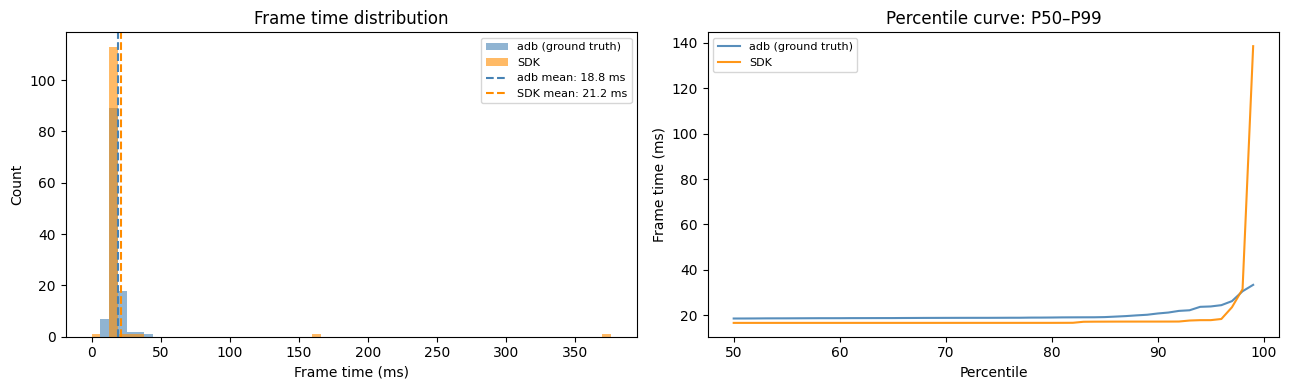

Frame time — adb:  mean=18.82 ms  P95=23.94 ms
Frame time — SDK:  mean=21.16 ms  P95=17.92 ms
KS test: statistic=0.8235  p-value=0.0000  (distributions differ)


In [ ]:
fig, axes = plt.subplots(1, 2 if sdk_frames_ok else 1, figsize=(13 if sdk_frames_ok else 7, 4))
axes = np.atleast_1d(axes)

ax = axes[0]
bins = np.linspace(0, frames_gt.max() if not sdk_frames_ok else max(frames_gt.max(), frames_sdk.max()), 60)
ax.hist(frames_gt, bins=bins, alpha=0.6, label='adb (ground truth)', color='steelblue')
if sdk_frames_ok:
    ax.hist(frames_sdk, bins=bins, alpha=0.6, label='SDK', color='darkorange')
ax.axvline(frames_gt.mean(), color='steelblue', linestyle='--', linewidth=1.5,
           label=f'adb mean: {frames_gt.mean():.1f} ms')
if sdk_frames_ok:
    ax.axvline(frames_sdk.mean(), color='darkorange', linestyle='--', linewidth=1.5,
               label=f'SDK mean: {frames_sdk.mean():.1f} ms')
ax.set_xlabel('Frame time (ms)')
ax.set_ylabel('Count')
ax.set_title('Frame time distribution')
ax.legend(fontsize=8)

if sdk_frames_ok:
    ax2 = axes[1]
    percentiles = np.arange(50, 100, 1)
    gt_pcts  = np.percentile(frames_gt.dropna(),  percentiles)
    sdk_pcts = np.percentile(frames_sdk.dropna(), percentiles)
    ax2.plot(percentiles, gt_pcts,  label='adb (ground truth)', color='steelblue',  alpha=0.9)
    ax2.plot(percentiles, sdk_pcts, label='SDK',                color='darkorange', alpha=0.9)
    ax2.set_xlabel('Percentile')
    ax2.set_ylabel('Frame time (ms)')
    ax2.set_title('Percentile curve: P50–P99')
    ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{ACC}/accuracy_frames.png', dpi=150)
plt.show()

print(f"Frame time — adb:  mean={frames_gt.mean():.2f} ms  P95={np.percentile(frames_gt.dropna(), 95):.2f} ms")
if sdk_frames_ok:
    print(f"Frame time — SDK:  mean={frames_sdk.mean():.2f} ms  P95={np.percentile(frames_sdk.dropna(), 95):.2f} ms")
    ks_stat, ks_p = stats.ks_2samp(frames_gt.dropna(), frames_sdk.dropna())
    print(f"KS test: statistic={ks_stat:.4f}  p-value={ks_p:.4f}  ({'distributions match' if ks_p > 0.05 else 'distributions differ'})")
else:
    print("SDK frame data not available — run measure_accuracy.sh with a project_id.")